In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

from torch.utils.data import DataLoader

sys.path.append('../../PerturbVAE/')

from model import *
from utils import *
from dataset import *
from train import *

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = sc.read_h5ad('data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)]

In [3]:
dataset = PerturbDataset(data)

In [4]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# Example: Iterate through the DataLoader
for X, P, C in dataloader:
    print("Batch X shape:", X.shape)
    print("Batch P:", P)
    print("Batch C:", C)
    break

Batch X shape: torch.Size([128, 2218])
Batch P: tensor([23, 22, 31, 51,  3,  9,  0, 93, 66, 42, 72, 84, 55,  9, 13, 82, 78, 79,
        88, 23, 84, 35, 13, 56, 32, 16, 13,  6, 73,  6, 66, 66, 77, 22, 93, 28,
        14, 34, 64, 81, 22, 23, 28, 42, 85, 38, 88, 85, 51, 56, 74, 81, 90, 76,
        66, 32, 60, 76, 31, 12, 85, 43, 84, 78, 58, 43, 86, 89,  4, 84, 36, 66,
        56, 95, 85,  8, 30, 93, 15, 53, 72, 94, 93, 52, 16, 49, 24, 90, 89, 83,
        13, 68, 22, 91, 35, 55, 73, 18,  0, 96, 33, 85, 84, 40, 32, 66, 47, 36,
        85, 65, 34, 91, 72, 20, 66,  9, 44, 29, 89, 90, 22, 25, 88, 78, 59, 85,
        18, 81])
Batch C: tensor([0, 0, 3, 3, 2, 2, 2, 1, 1, 0, 2, 2, 0, 0, 1, 1, 1, 1, 0, 3, 1, 1, 3, 3,
        0, 2, 3, 1, 1, 2, 0, 0, 0, 2, 3, 3, 2, 3, 2, 1, 0, 2, 3, 0, 1, 0, 2, 0,
        0, 1, 2, 1, 0, 3, 3, 3, 1, 0, 2, 1, 3, 1, 1, 3, 2, 2, 0, 0, 1, 1, 0, 0,
        3, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0, 2, 3, 0, 2, 0, 2, 0, 3, 0, 1, 2, 2, 3,
        1, 0, 0, 0, 1, 0, 3, 2, 0, 3, 3, 2, 2,

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
hyper_config = HyperparamConfig()
hyper_config.n_genes = data.shape[-1]
hyper_config.n_conditions = len(np.unique(dataset.C_indices))
hyper_config.n_perturb = len(np.unique(dataset.P_indices))

In [7]:
config = LitConfig()
model = PerturbVAE(config=hyper_config)
trainer_config = TrainerConfig()
trainer_config.max_epochs = 10
trainer_config.force_cpu = False

In [8]:
# from importlib import reload

# from model import PerturbVAE

# import model as m

# reload(m)

In [ ]:
config.lr = 1e-3

In [17]:
pyro.clear_param_store()

train_(model, config, dataloader, val_loader=None, trainer_config=trainer_config)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/envs/perturb/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
/opt/conda/envs/perturb/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode 
--------------------------------------------------
0 | full_model | PerturbVAE | 1.7 M  | eval 
1 | loss_fn    | ELBOModule | 0      | train
2 | predictive | Predictive | 0      | train
--------------------------------------------------
1.7 M     Trainabl

Epoch 9: 100%|██████████| 141/141 [00:07<00:00, 17.85it/s, v_num=0xwl]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 141/141 [00:07<00:00, 17.85it/s, v_num=0xwl]


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█████
train_diversity_reg,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁
train_elbo,▆▇▅█▅▂▄▇▆▃▅▅▄▄▃▅▅▃▅▄▅▆▇▄▄▄▅▅▂▆▁▄▄▆▆▄▄▃▂▄
train_hsic,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▄▄▄▄▅▅▄▂▅▃▃▄▄▄▃▅▄▃▂▁▄▄▃▄▄▃▃▄▄▄▄▄▃▃▃▁▁▂▂
train_mse,▃▁▂▃▃▂▃▃▂▃▅▂▁▂▂▄▁▄▃▂▁▄▄▁▁▂▃▃▂▄▂▂▄▃▃▄▂█▄▂
train_total_L1,█▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇████
epoch,9
train_diversity_reg,-0.00011
train_elbo,259147.125


In [27]:
import pyro.poutine as poutine

model.device = torch.device('cpu')
model.eval()
model = model.to(model.device)


X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

trace = poutine.trace(model.guide).get_trace(X, P, C)

/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


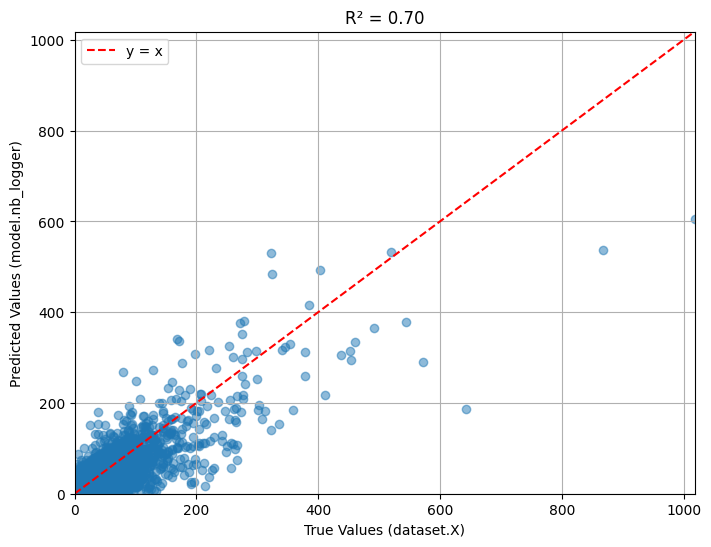

In [28]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

prediction = model.nb_logger

r2 = r2_score(dataset.X.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, dataset.X.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = dataset.X[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values (dataset.X)")
plt.ylabel("Predicted Values (model.nb_logger)")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [14]:
rho = trace.nodes["rho"]["value"]

batch_indices = torch.arange(rho.size(0))
rho_at_P = rho[batch_indices, P, :]  # shape: [batch, latent_dim]

data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


/var/tmp/ipykernel_722080/40902191.py:6: ImplicitModificationWarning: Setting element `.obsm['rho']` of view, initializing view as actual.
  data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


In [ ]:
sc.pp.neighbors(data, use_rep='rho', n_neighbors=15)

sc.tl.leiden(data, resolution=1.0)
sc.tl.umap(data)

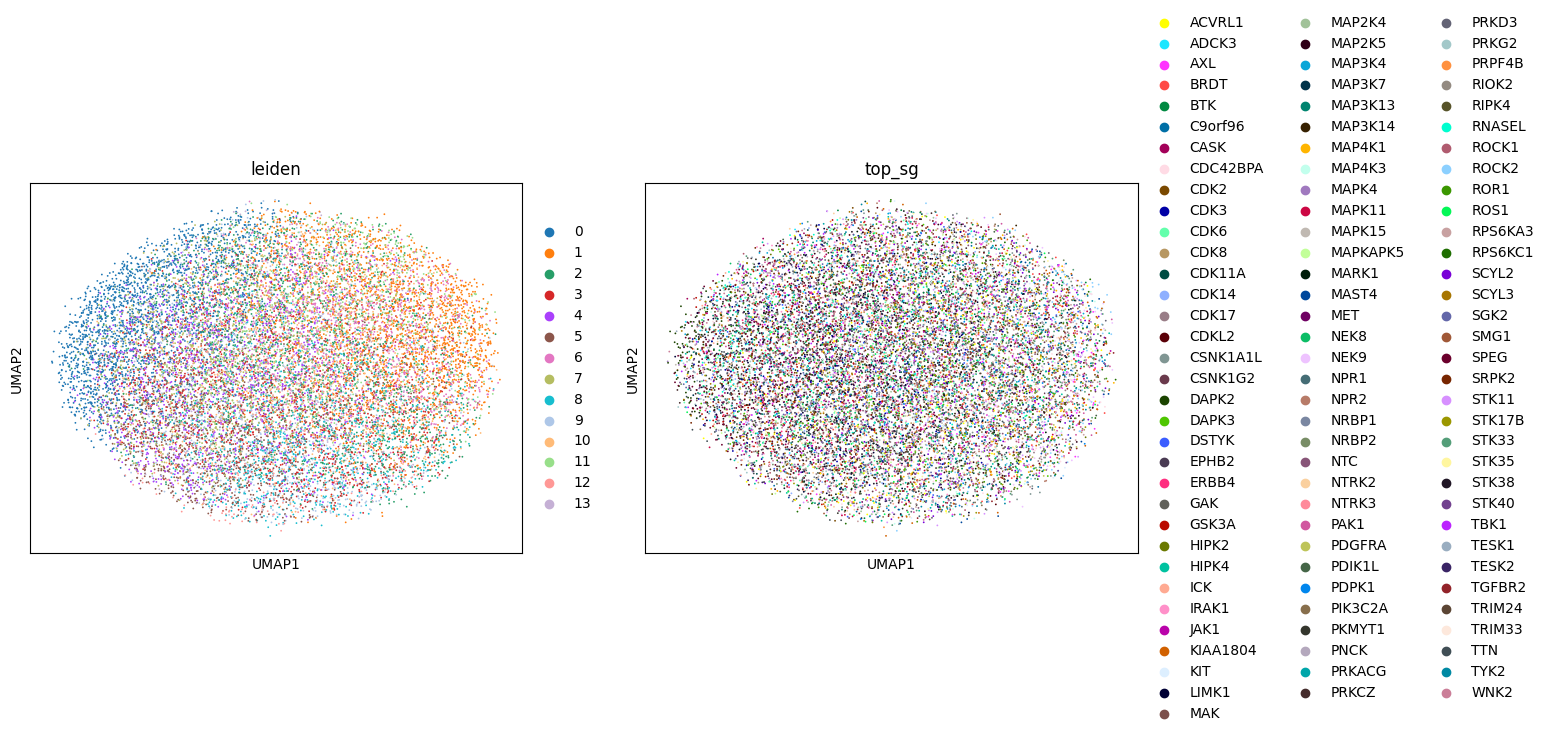

In [16]:
sc.pl.umap(data, color=['leiden', 'top_sg'])